In [2]:
from cosipy.response.ideal_response import (
    IdealComptonIRF,
    UnpolarizedIdealComptonIRF,
    ExpectationFromLineInSCFrame,
    RandomEventDataFromContinuumInSCFrame,
)

from threeML import Powerlaw

import astropy.units as u
from astropy.coordinates import SkyCoord
from scoords import SpacecraftFrame

import matplotlib.pyplot as plt
%matplotlib inline

# Define a point source

In [3]:
# define spectrum
index = -2.2
K = 0.3 / u.cm / u.cm / u.s / u.keV
piv = 100 * u.keV
spectrum = Powerlaw()
spectrum.index.value = index
spectrum.K.value = K.value
spectrum.piv.value = piv.value 
spectrum.K.unit = K.unit
spectrum.piv.unit = piv.unit

# define energy range to simulate
energy_min = 100 * u.keV
energy_max = 10000 * u.keV

# define source diretion
direction = SkyCoord(lon = 0, lat = 60, unit = 'deg', frame = SpacecraftFrame())

# define source duration
duration = 10*u.s

# Simulate events

In [4]:
# define unpolarized response
irf_unpol = UnpolarizedIdealComptonIRF.cosi_like()

# initialize the simulation
data = RandomEventDataFromContinuumInSCFrame(
    irf=irf_unpol,
    spectrum=spectrum,
    direction=direction,
    duration=duration,
    energy_max=energy_max,
    energy_min=energy_min,
)

In [5]:
# You can check the number of photons detected
data.unpol_counts.total_expected_counts

<Quantity 4598. ph>

In [6]:
# Start simulation
data.simulate_events()

Simulating energy 9743.666  keV: 100%|█████████████████████████████████████████████████████████████████| 4598/4598 [01:20<00:00, 56.78it/s]


# Make some plots

In [7]:
measured_energy = data.energy
phi = data.scattering_angle
psichi = data.scattered_direction_sc

## Plot effective area as a function of energy

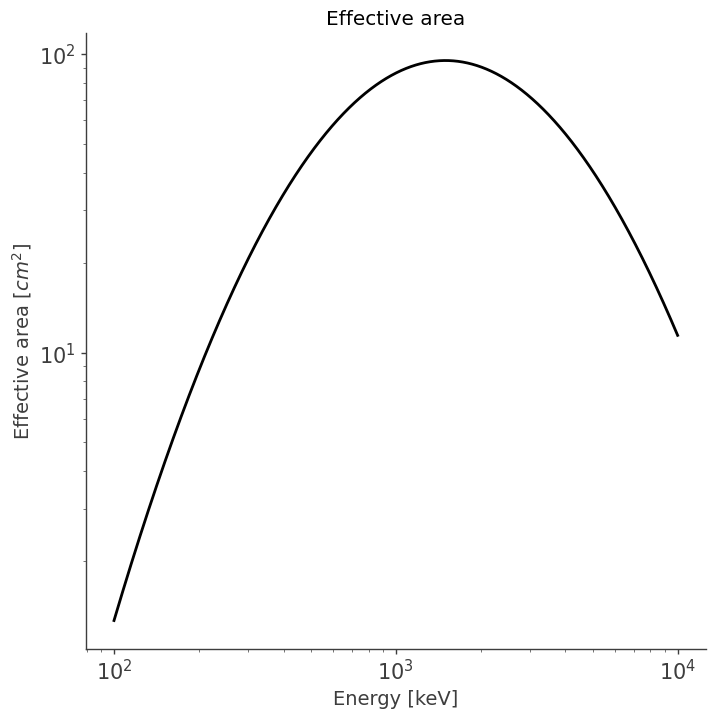

In [8]:
fig, ax = plt.subplots(figsize=(8,8), sharex=False, nrows=1) ##sharex=True

energy_grid = data.energy_grid

ax.plot(data.energy_grid, data.unpolarized_aeff, color="black")
ax.set_xlabel("Energy [keV]")
ax.set_ylabel(r"Effective area [$cm^2$]")
ax.set_xscale("log")
ax.set_yscale("log")


plt.title("Effective area")
plt.tick_params(axis="both", which="both", labelleft=True, labelright=False, labelbottom=True, labeltop=False, labelsize = 15)

plt.xticks(fontsize=15)
plt.yticks(fontsize=15);


## Plot measured count spectrum

''

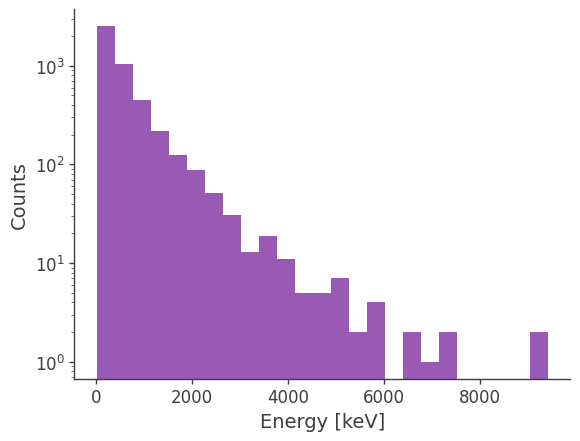

In [9]:
# We can plot a histogram of the count spectrum
# However, this only returns a binned plot although
# the data itself is unbinned

plt.hist(measured_energy.value)
plt.xlabel("Energy [keV]")
plt.yscale("log")
plt.ylabel("Counts")
;

## Plot Empirical Cumulative Distribution Function (ECDF)

We can use ECDF as an alternative way to visualize the distribution of unbinned event energies.

Empirical CDF is computed from observed events. It’s a step function that jumps by $\dfrac{1}{N}$ at each observation (or at each unique value, if there are repeats).  

It shows the cumulative fraction of events below a value:

$\hat{F}(x)=\frac{1}{N} \sum_{i=1}^N \mathbf{1}\left(E_i \leq x\right)$

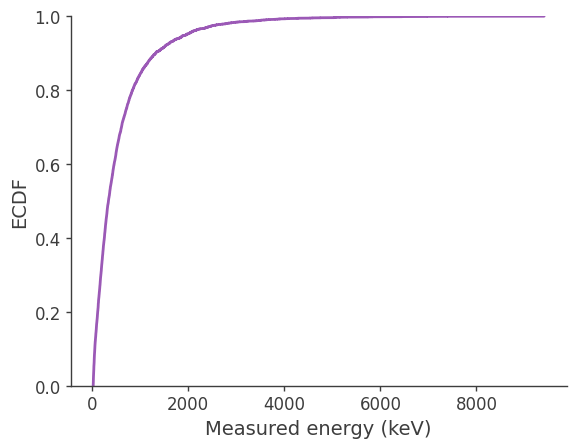

In [10]:
from scipy.stats import ecdf

res = ecdf(measured_energy.value) 
x = res.cdf.quantiles
y = res.cdf.probabilities

fig, ax = plt.subplots()
ax.step(x, y, where="post")
ax.set_xlabel("Measured energy (keV)")
ax.set_ylabel("ECDF")
ax.set_ylim(0, 1)
plt.show()

## Plot PsiChi distribution

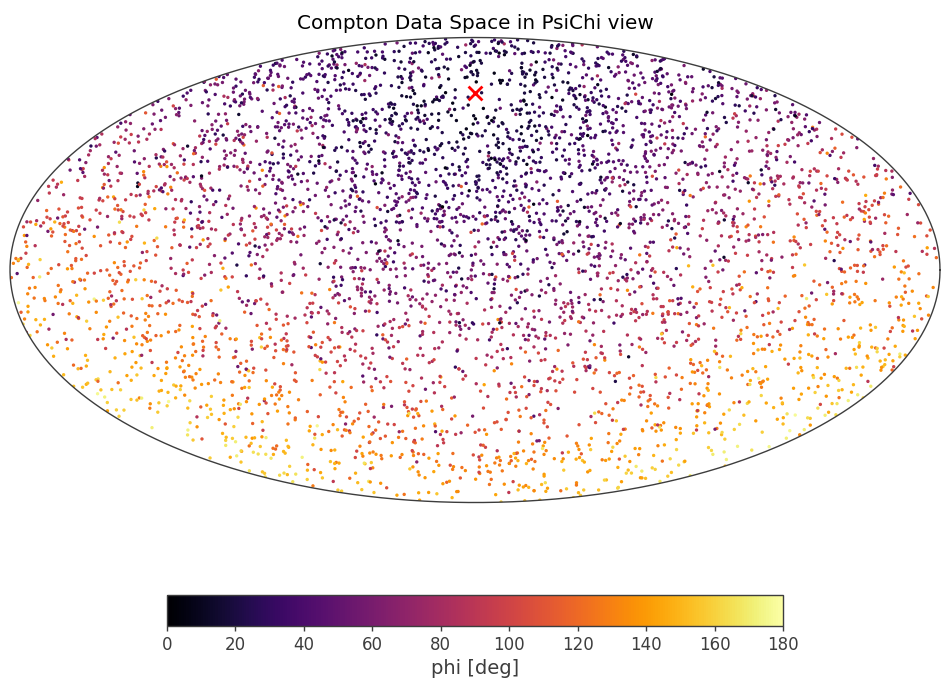

In [11]:
fig, ax = plt.subplots(figsize=(12,8), sharex=False, nrows=1)

ax.set_axis_off() # Replace corner plot with axis suitable for spherical data
sph_ax = fig.add_subplot(projection = 'mollview')

sc = sph_ax.scatter(psichi.lon.deg, psichi.lat.deg, transform = sph_ax.get_transform('world'), c = phi.to_value('deg'), cmap = 'inferno',
                s = 2, vmin = 0, vmax = 180)
sph_ax.scatter(direction.lon.deg, direction.lat.deg, transform = sph_ax.get_transform('world'), marker = 'x', s = 100, c = 'red')
fig.colorbar(sc, orientation="horizontal", fraction = .05, label = "phi [deg]")

sph_ax.set_title("Compton Data Space in PsiChi view");

## Save Injected Data

In [12]:
data.save_data(
    "test.fits.gz",
)